# Analyse des ventes d'une entreprise — Online Retail (UK)

**Projet Data Analysis / Business Intelligence**

Objectif : analyser un an de transactions d'une entreprise réelle de vente en ligne (cadeaux et articles de décoration, Royaume-Uni) pour en tirer des indicateurs de performance, comprendre la saisonnalité des ventes, identifier les produits et marchés clés, et segmenter la clientèle.

## Origine des données

Le jeu de données **"Online Retail"** est publié par le [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail). Il recense les transactions réelles (anonymisées) d'une entreprise britannique de vente en ligne de cadeaux, entre le 1er décembre 2010 et le 9 décembre 2011 : 541 909 lignes de commande, 38 pays, plus de 4 300 clients identifiés.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Chargement des données

In [2]:
df = pd.read_excel("Online Retail.xlsx")
print("Dimensions :", df.shape)
df.head()


Dimensions : (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nPeriode couverte :", df["InvoiceDate"].min(), "-", df["InvoiceDate"].max())


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Valeurs manquantes :


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Periode couverte : 2010-12-01 08:26:00 - 2011-12-09 12:50:00


## 2. Nettoyage des données

Le fichier brut mélange ventes et annulations (numéro de facture préfixé par "C"), et contient des lignes à quantité ou prix négatif/nul. On sépare d'abord les annulations pour mesurer le taux de retour, puis on nettoie l'échantillon de travail.


In [4]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["is_cancelled"] = df["InvoiceNo"].str.startswith("C")

total_invoices = df["InvoiceNo"].nunique()
cancelled_invoices = df.loc[df["is_cancelled"], "InvoiceNo"].nunique()
return_rate = cancelled_invoices / total_invoices

print(f"Factures totales : {total_invoices:,}")
print(f"Factures annulees : {cancelled_invoices:,}")
print(f"Taux d'annulation : {return_rate:.1%}")


Factures totales : 25,900
Factures annulees : 3,836
Taux d'annulation : 14.8%


In [5]:
sales = df[~df["is_cancelled"]].copy()
sales = sales[(sales["Quantity"] > 0) & (sales["UnitPrice"] > 0)]
print("Lignes de vente valides :", len(sales))


Lignes de vente valides : 530104


### Détection d'une anomalie

Une ligne isolée enregistre 80 995 unités du produit "PAPER CRAFT , LITTLE BIRDIE" en une seule commande — plus du double de la plus grosse commande suivante sur l'ensemble du jeu de données. Il s'agit très probablement d'une erreur de saisie plutôt que d'une vente réelle : elle est retirée pour ne pas fausser l'analyse.


In [6]:
outlier_mask = (sales["InvoiceNo"] == "581483") & (sales["Description"] == "PAPER CRAFT , LITTLE BIRDIE")
print("Quantite retiree :", int(sales.loc[outlier_mask, "Quantity"].sum()))
print("Chiffre d'affaires retire : £{:,.0f}".format((sales.loc[outlier_mask, "Quantity"] * sales.loc[outlier_mask, "UnitPrice"]).sum()))
sales = sales[~outlier_mask]

sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]
sales["Month"] = sales["InvoiceDate"].dt.to_period("M").astype(str)
sales["DayOfWeek"] = sales["InvoiceDate"].dt.dayofweek
sales["Hour"] = sales["InvoiceDate"].dt.hour


Quantite retiree : 80995
Chiffre d'affaires retire : £168,470


## 3. Indicateurs clés (KPI)

In [7]:
total_revenue = sales["Revenue"].sum()
avg_order_value = sales.groupby("InvoiceNo")["Revenue"].sum().mean()
n_orders = sales["InvoiceNo"].nunique()
n_customers = sales["CustomerID"].dropna().nunique()

print(f"Chiffre d'affaires total : £{total_revenue:,.0f}")
print(f"Nombre de commandes : {n_orders:,}")
print(f"Clients identifies : {n_customers:,}")
print(f"Panier moyen : £{avg_order_value:,.2f}")


Chiffre d'affaires total : £10,498,215
Nombre de commandes : 19,959
Clients identifies : 4,338
Panier moyen : £525.99


## 4. Évolution mensuelle du chiffre d'affaires

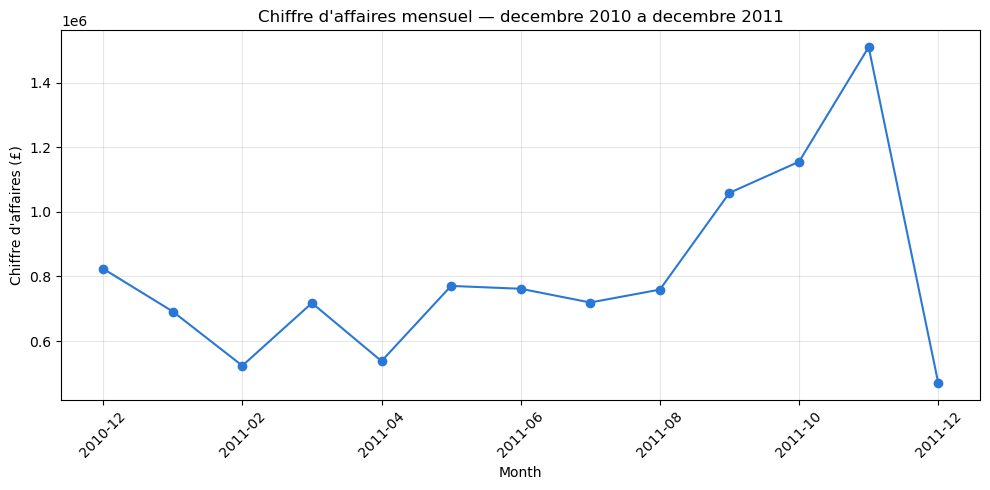

In [8]:
monthly = sales.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10, 5))
monthly.plot(kind="line", marker="o", color="#2a78d6")
plt.ylabel("Chiffre d'affaires (£)")
plt.title("Chiffre d'affaires mensuel — decembre 2010 a decembre 2011")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("revenu_mensuel.png", dpi=120)
plt.show()


Le chiffre d'affaires progresse fortement à partir de septembre 2011 et culmine en novembre (achats de fin d'année). Le mois de décembre 2011 est incomplet (données arrêtées au 9 décembre), ce qui explique la baisse apparente en fin de série.

## 5. Saisonnalité : jour de la semaine et heure de la journée

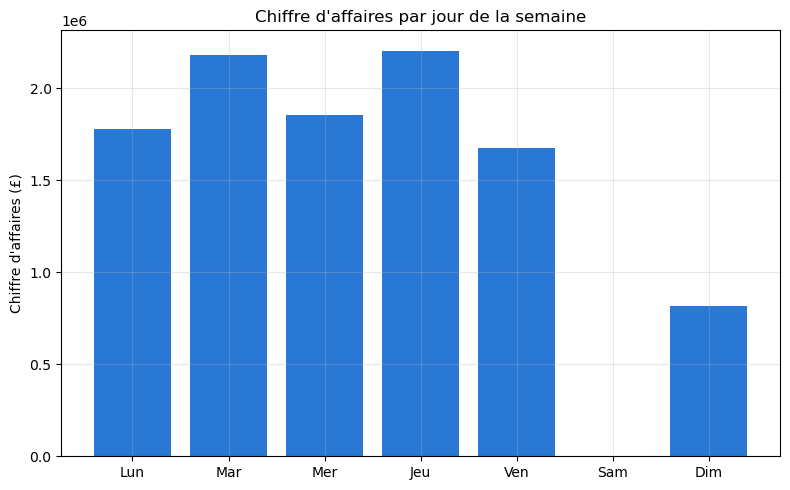

In [9]:
by_dow = sales.groupby("DayOfWeek")["Revenue"].sum().reindex(range(7), fill_value=0)
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

plt.figure(figsize=(8, 5))
plt.bar(jours, by_dow.values, color="#2a78d6")
plt.ylabel("Chiffre d'affaires (£)")
plt.title("Chiffre d'affaires par jour de la semaine")
plt.tight_layout()
plt.show()


Aucune vente n'est enregistrée le samedi : l'entreprise n'expédie/ne facture pas ce jour-là, une caractéristique réelle de son fonctionnement plutôt qu'un artefact des données.

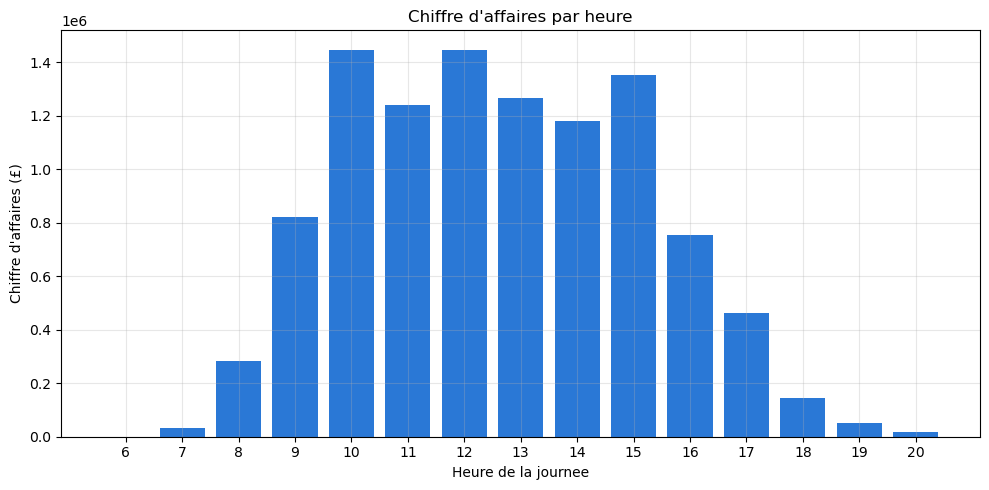

In [10]:
by_hour = sales.groupby("Hour")["Revenue"].sum()

plt.figure(figsize=(10, 5))
plt.bar(by_hour.index.astype(str), by_hour.values, color="#2a78d6")
plt.xlabel("Heure de la journee")
plt.ylabel("Chiffre d'affaires (£)")
plt.title("Chiffre d'affaires par heure")
plt.tight_layout()
plt.show()


## 6. Produits phares

On exclut les lignes qui ne correspondent pas à un produit physique (frais de port, ajustements manuels, bons cadeaux) pour ne classer que de vraies références.

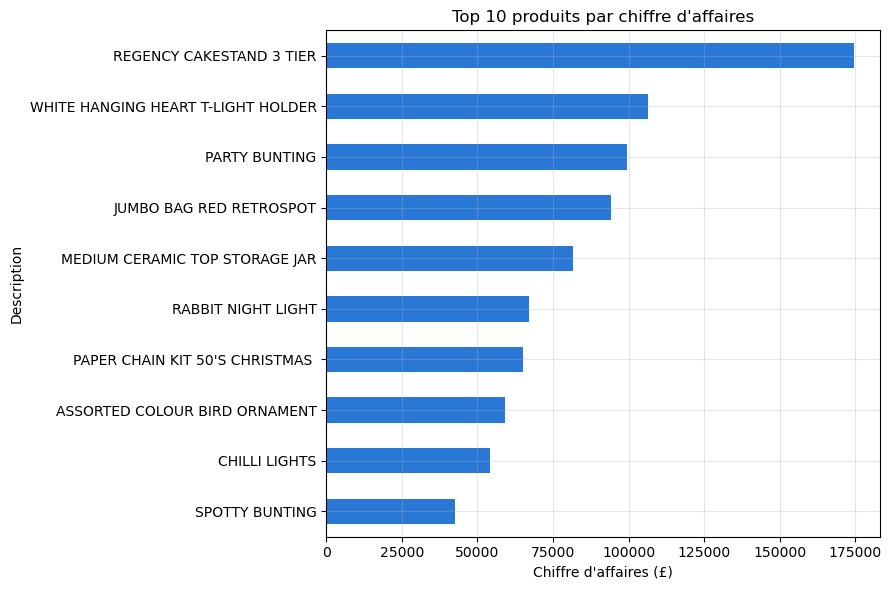

In [11]:
non_product_codes = {"POST", "DOT", "M", "m", "C2", "BANK CHARGES", "PADS", "AMAZONFEE", "S",
                      "gift_0001_10", "gift_0001_20", "gift_0001_30", "gift_0001_40", "gift_0001_50"}
products_only = sales[~sales["StockCode"].astype(str).isin(non_product_codes)]

top_rev = products_only.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
top_rev.sort_values().plot(kind="barh", color="#2a78d6")
plt.xlabel("Chiffre d'affaires (£)")
plt.title("Top 10 produits par chiffre d'affaires")
plt.tight_layout()
plt.show()


## 7. Répartition géographique des ventes

Part du Royaume-Uni dans le chiffre d'affaires : 84.4%


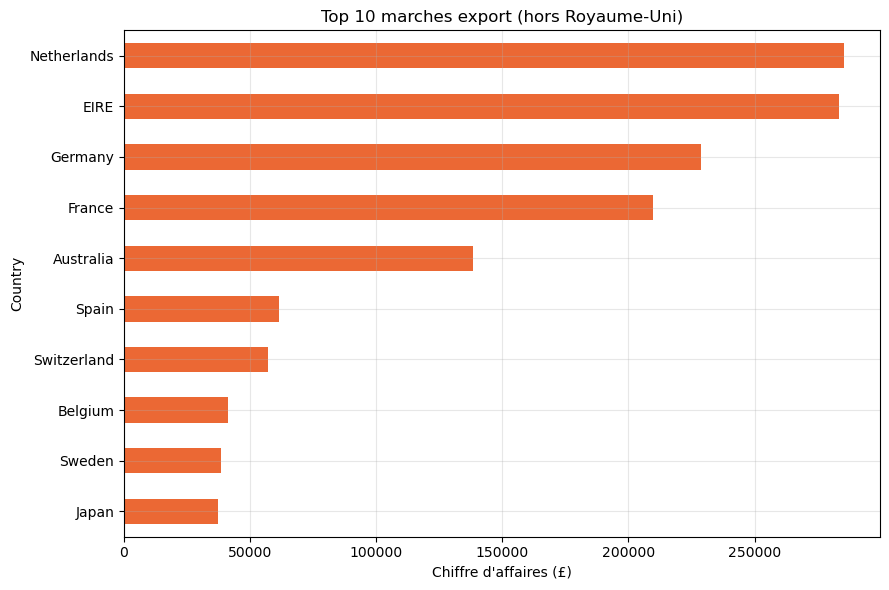

In [12]:
by_country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
uk_share = by_country["United Kingdom"] / by_country.sum()
print(f"Part du Royaume-Uni dans le chiffre d'affaires : {uk_share:.1%}")

top_export = by_country.drop("United Kingdom").head(10)

plt.figure(figsize=(9, 6))
top_export.sort_values().plot(kind="barh", color="#eb6834")
plt.xlabel("Chiffre d'affaires (£)")
plt.title("Top 10 marches export (hors Royaume-Uni)")
plt.tight_layout()
plt.show()


## 8. Segmentation client (analyse RFM)

On segmente les clients identifiés selon trois dimensions : **Récence** (jours depuis le dernier achat), **Fréquence** (nombre de commandes) et **Montant** (chiffre d'affaires généré). Chaque dimension est découpée en quartiles, puis combinée en segments métier.


In [13]:
cust = sales.dropna(subset=["CustomerID"]).copy()
snapshot = cust["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = cust.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
)

rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=range(4, 0, -1), duplicates="drop").astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=range(1, 5), duplicates="drop").astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"], 4, labels=range(1, 5), duplicates="drop").astype(int)

def segment(row):
    if row["R"] >= 4 and row["F"] >= 4 and row["M"] >= 4:
        return "Champions"
    if row["F"] >= 3 and row["M"] >= 3:
        return "Fideles"
    if row["R"] <= 2 and row["F"] >= 3:
        return "A risque"
    if row["R"] >= 4 and row["F"] <= 2:
        return "Nouveaux"
    if row["R"] <= 2 and row["F"] <= 2:
        return "Perdus"
    return "Reguliers"

rfm["Segment"] = rfm.apply(segment, axis=1)
rfm[["Recency", "Frequency", "Monetary", "Segment"]].head()


,Recency,Frequency,Monetary,Segment
CustomerID,,,,
12346.0,326,1,77183.60,Perdus
12347.0,2,7,4310.00,Champions
12348.0,75,4,1797.24,Fideles
12349.0,19,1,1757.55,Reguliers
12350.0,310,1,334.40,Perdus


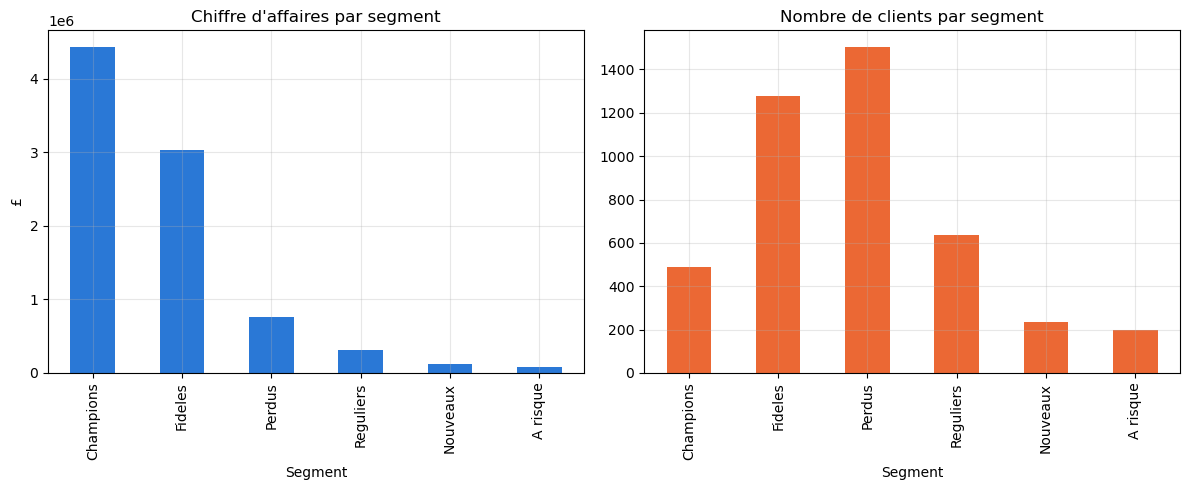

                  CA  Clients  CA moyen/client
Segment                                       
Champions  4436405.0      491           9035.0
Fideles    3028165.0     1277           2371.0
Perdus      767150.0     1505            510.0
Reguliers   309112.0      635            487.0
Nouveaux    119202.0      233            512.0
A risque     82904.0      197            421.0


In [14]:
seg_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
seg_count = rfm.groupby("Segment").size().reindex(seg_revenue.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
seg_revenue.plot(kind="bar", ax=axes[0], color="#2a78d6")
axes[0].set_title("Chiffre d'affaires par segment")
axes[0].set_ylabel("£")
seg_count.plot(kind="bar", ax=axes[1], color="#eb6834")
axes[1].set_title("Nombre de clients par segment")
plt.tight_layout()
plt.show()

print(pd.DataFrame({"CA": seg_revenue, "Clients": seg_count, "CA moyen/client": seg_revenue/seg_count}).round(0))


## 9. Concentration de la valeur client (courbe de Pareto)

Les 20% de clients les plus actifs generent 74.1% du chiffre d'affaires (clients identifies).


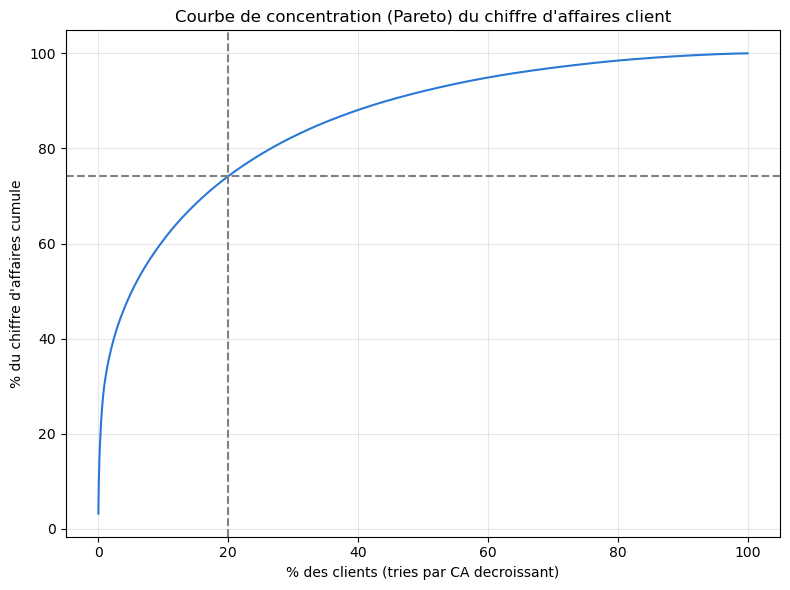

In [15]:
sorted_monetary = rfm["Monetary"].sort_values(ascending=False).values
cum_revenue_pct = np.cumsum(sorted_monetary) / sorted_monetary.sum() * 100
cum_customers_pct = np.arange(1, len(sorted_monetary) + 1) / len(sorted_monetary) * 100

n20 = int(len(sorted_monetary) * 0.2)
top20_share = np.cumsum(sorted_monetary)[n20 - 1] / sorted_monetary.sum() * 100
print(f"Les 20% de clients les plus actifs generent {top20_share:.1f}% du chiffre d'affaires (clients identifies).")

plt.figure(figsize=(8, 6))
plt.plot(cum_customers_pct, cum_revenue_pct, color="#2a78d6")
plt.axvline(20, linestyle="--", color="gray")
plt.axhline(top20_share, linestyle="--", color="gray")
plt.xlabel("% des clients (tries par CA decroissant)")
plt.ylabel("% du chiffre d'affaires cumule")
plt.title("Courbe de concentration (Pareto) du chiffre d'affaires client")
plt.tight_layout()
plt.savefig("pareto_clients.png", dpi=120)
plt.show()


## 10. Conclusion

Cette analyse met en œuvre une démarche complète de Data Analysis sur des **données réelles de vente** :

- nettoyage rigoureux (annulations, valeurs aberrantes, codes non-produits) ;
- indicateurs clés de performance (CA, panier moyen, taux de retour) ;
- analyse temporelle (saisonnalité mensuelle, hebdomadaire, horaire) ;
- analyse produits et marchés (top produits, répartition géographique) ;
- segmentation client par la méthode RFM et analyse de concentration (Pareto).

### Compétences mobilisées

**Python · Pandas · NumPy · Matplotlib · Analyse RFM · Nettoyage de données · Analyse temporelle · Business Intelligence**

### Limites

L'entreprise vend essentiellement à des professionnels (revendeurs) plutôt qu'à des particuliers, ce qui explique des paniers moyens élevés (~£526). Environ 16,7% du chiffre d'affaires provient d'achats sans identifiant client, exclus de la segmentation RFM.
